In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html
from dash.dependencies import Input, Output
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Data Loading and Cleaning

df_air_quality_city = pd.read_csv("filtered data/air_quality_city.csv")
df_forest_cover = pd.read_csv("filtered data/forest-cover-v1.csv")
df_global_pm25 = pd.read_csv("filtered data/GlobalPM25-1998-2022.csv")
df_global_weather = pd.read_csv("filtered data/GlobalWeatherRepository.csv")
df_traffic_list = pd.read_csv("filtered data/trafficlist_forcountry.csv")

df_air_quality_city['Annual mean, ug/m3'] = df_air_quality_city['Annual mean, ug/m3'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df_air_quality_city.dropna(subset=['Annual mean, ug/m3'], inplace=True)  # Drop rows where conversion failed

df_traffic_list['Vehicles'] = df_traffic_list['Vehicles'].astype(str).str.replace(',', '', regex=False)
df_traffic_list['Vehicles'] = pd.to_numeric(df_traffic_list['Vehicles'], errors='coerce')
df_traffic_list.dropna(subset=['Vehicles'], inplace=True)  # Drop rows where conversion failed


In [3]:
# Merge DataFrames
print("Unique values in df_global_pm25['Country']:", df_global_pm25['Country'].unique())
print("Unique values in df_forest_cover['Country Name']:", df_forest_cover['Country Name'].unique())
print("Unique values in df_traffic_list['Country']:", df_traffic_list['Country'].unique())

# Standardize Country Names
df_forest_cover['Country'] = df_forest_cover['Country Name']  
df_global_pm25['Country'] = df_global_pm25['Country'].str.strip()
df_forest_cover['Country'] = df_forest_cover['Country'].str.strip()
df_traffic_list['Country'] = df_traffic_list['Country'].str.strip()

# Merging with standardized 'Country' column
df_merged_pm25_forest = pd.merge(df_global_pm25, df_forest_cover, on='Country', how='inner')

# Merging the above with Traffic List on 'Country'
df_merged_all = pd.merge(df_merged_pm25_forest, df_traffic_list, on='Country', how='inner')



Unique values in df_global_pm25['Country']: ['Aruba' 'Afghanistan' 'Angola' 'Anguilla' 'Aland' 'Albania' 'Andorra'
 'United Arab Emirates' 'Argentina' 'Armenia' 'American Samoa'
 'Antigua and Barbuda' 'Australia' 'Austria' 'Azerbaijan' 'Burundi'
 'Belgium' 'Benin' 'Bonaire; Sint Eustatius and Saba' 'Burkina Faso'
 'Bangladesh' 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia and Herzegovina'
 'Saint-Barthélemy' 'Belarus' 'Belize' 'Bermuda' 'Bolivia' 'Brazil'
 'Barbados' 'Brunei' 'Bhutan' 'Botswana' 'Central African Republic'
 'Canada' 'Cocos Islands' 'Switzerland' 'Chile' 'China' "Côte d'Ivoire"
 'Cameroon' 'Democratic Republic of the Congo' 'Republic of Congo'
 'Cook Islands' 'Colombia' 'Comoros' 'Cape Verde' 'Costa Rica' 'Cuba'
 'Curaçao' 'Christmas Island' 'Cayman Islands' 'Cyprus' 'Czech Republic'
 'Germany' 'Djibouti' 'Dominica' 'Denmark' 'Dominican Republic' 'Algeria'
 'Ecuador' 'Egypt' 'Eritrea' 'Western Sahara' 'Spain' 'Estonia' 'Ethiopia'
 'Finland' 'Fiji' 'Falkland Islands' 'France' 'F

In [4]:
# Time Series of PM2.5 (Interactive Dash App)

app = Dash(__name__)

app.layout = html.Div([
    html.H1("PM2.5 Time Series Over Years", style={'textAlign': 'center', 'color': '#333'}),
    html.Div([
        html.Label("Select Countries:", style={'fontWeight': 'bold', 'marginRight': '10px'}),
        dcc.Dropdown(
            id='country-dropdown',
            options=[{'label': country, 'value': country} for country in df_merged_all['Country'].unique()],
            value=df_merged_all['Country'].unique()[0] if len(df_merged_all['Country'].unique()) > 0 else None,
            multi=True, # Allows selecting multiple countries
            placeholder="Select one or more countries...",
            style={'width': '100%', 'maxWidth': '600px'}
        ),
    ], style={'display': 'flex', 'justifyContent': 'center', 'marginBottom': '20px'}),
    dcc.Graph(id='pm25-time-series-graph', style={'height': '600px'})
], style={'fontFamily': 'Arial, sans-serif', 'padding': '20px', 'backgroundColor': '#f9f9f9'})

@app.callback(
    Output('pm25-time-series-graph', 'figure'),
    [Input('country-dropdown', 'value')]
)
def update_graph(selected_countries):
    if not selected_countries: 
        return go.Figure().update_layout(title="Please select at least one country to view PM2.5 trends.")

    if not isinstance(selected_countries, list):
        selected_countries = [selected_countries]

    filtered_df = df_merged_all[df_merged_all['Country'].isin(selected_countries)]
    fig = px.line(filtered_df, x='Year_x', y='Population-Weighted PM2.5 [ug/m3]', color='Country',
                  title='Population-Weighted PM2.5 Levels Over Time',
                  labels={'Year_x': 'Year', 'Population-Weighted PM2.5 [ug/m3]': 'PM2.5 (ug/m³)'},
                  template='plotly_white')
    fig.update_layout(hovermode="x unified")
    return fig

if __name__ == '__main__':
    app.run(debug=True, port=5083)

print("Dash app is running on http://localhost:5083/")

Dash app is running on http://localhost:5083/


In [5]:
def create_pm25_choropleth_map(df, year):
    """
    Creates a choropleth map of PM2.5 levels for a specific year.

    Args:
        df (pd.DataFrame): DataFrame containing PM2.5 data with 'Country' and 
                           'Population-Weighted PM2.5 [ug/m3]' columns.
        year (int): The year for which to create the map.

    Returns:
        plotly.graph_objects._figure.Figure: The choropleth map figure.
    """

    df_year = df[df['Year_x'] == year]  

    fig = px.choropleth(df_year,
                        locations='Country',  
                        locationmode="country names",  
                        color='Population-Weighted PM2.5 [ug/m3]',  
                        color_continuous_scale=px.colors.sequential.Plasma,
                        title=f'Population-Weighted PM2.5 Levels ({year})',
                        labels={'Population-Weighted PM2.5 [ug/m3]': 'PM2.5 (ug/m³)'})  

    fig.update_geos(fitbounds="locations", visible=False)  

    return fig

pm25_map = create_pm25_choropleth_map(df_merged_all, 2020)
pm25_map.show()

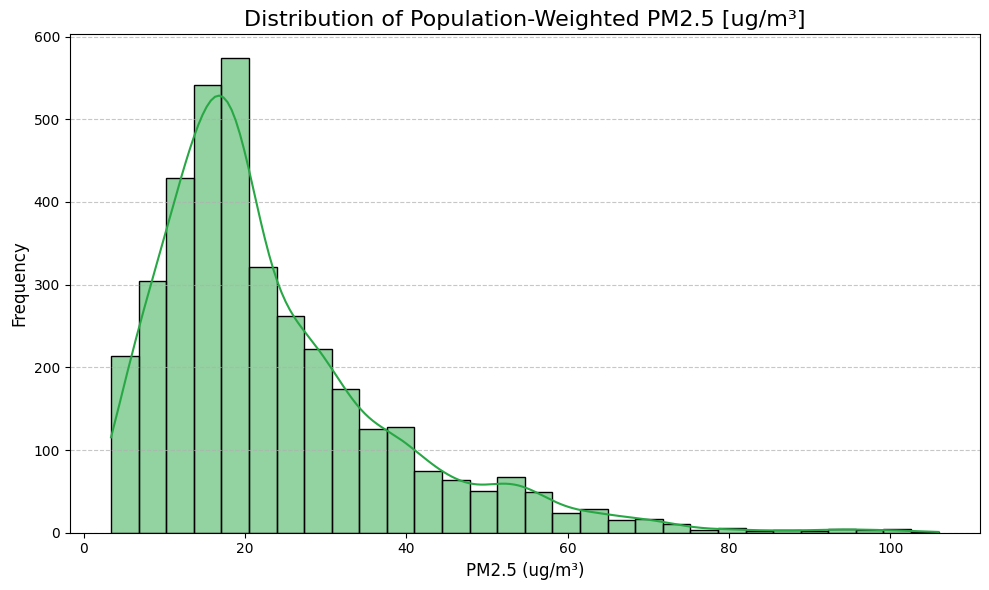

In [6]:
# Histogram: Distribution of Population-Weighted PM2.5

plt.figure(figsize=(10, 6))
sns.histplot(df_merged_all['Population-Weighted PM2.5 [ug/m3]'], kde=True, bins=30, color='#28a745')
plt.title('Distribution of Population-Weighted PM2.5 [ug/m³]', fontsize=16)
plt.xlabel('PM2.5 (ug/m³)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

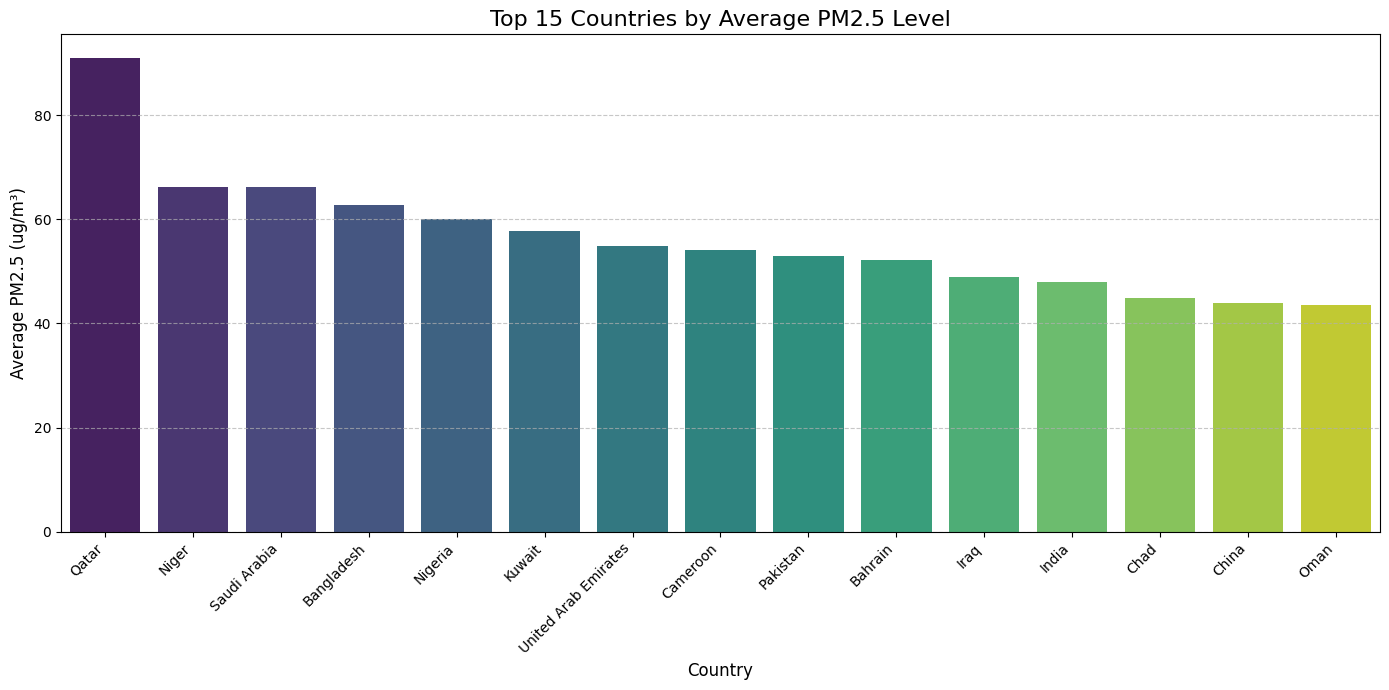

In [7]:
# Bar Chart: Top 15 Countries by Average PM2.5

df_pm25_agg = df_merged_all.groupby('Country')['Population-Weighted PM2.5 [ug/m3]'].mean().reset_index()

top_15_pm25 = df_pm25_agg.nlargest(15, 'Population-Weighted PM2.5 [ug/m3]')

plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Population-Weighted PM2.5 [ug/m3]', data=top_15_pm25, hue='Country', palette='viridis', legend=False)
plt.title('Top 15 Countries by Average PM2.5 Level', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average PM2.5 (ug/m³)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

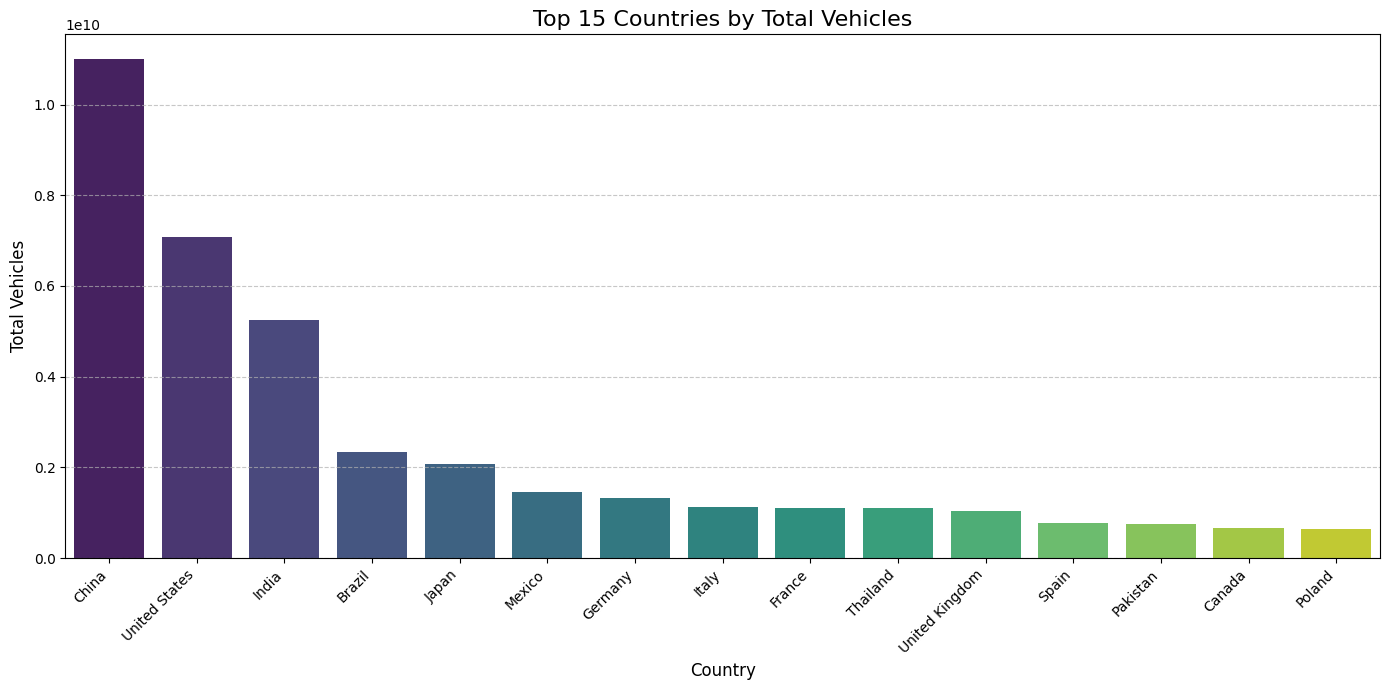

In [8]:
# Bar Chart: Top 15 Countries by Vehicle Count

df_traffic_agg = df_merged_all.groupby('Country')['Vehicles'].sum().reset_index()
top_15_vehicles = df_traffic_agg.nlargest(15, 'Vehicles')

plt.figure(figsize=(14, 7))
sns.barplot(x='Country', y='Vehicles', data=top_15_vehicles, hue='Country', palette='viridis', legend=False)
plt.title('Top 15 Countries by Total Vehicles', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Vehicles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

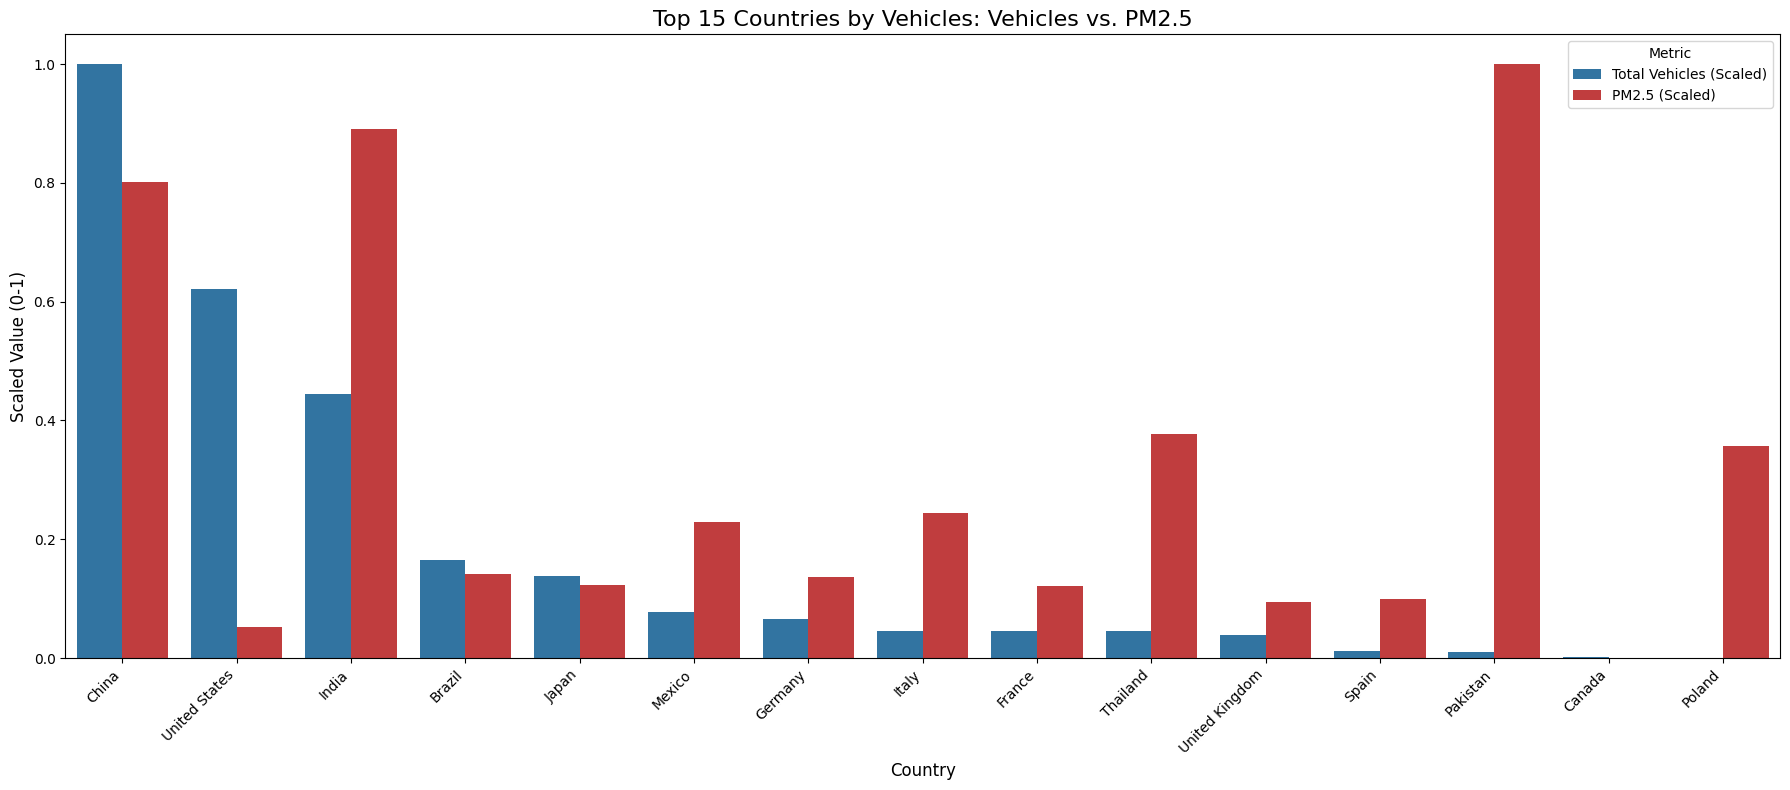

In [9]:
df_traffic_agg = df_merged_all.groupby('Country')['Vehicles'].sum().reset_index()
top_15_vehicles = df_traffic_agg.nlargest(15, 'Vehicles').copy() # Use a copy to avoid modifying the original

df_pm25_agg = df_merged_all.groupby('Country')['Population-Weighted PM2.5 [ug/m3]'].mean().reset_index()

df_combined = pd.merge(top_15_vehicles[['Country']], df_pm25_agg, on='Country', how='left')

# Scale the PM2.5 values
scaler_pm25 = MinMaxScaler()
df_combined['PM2.5 Scaled'] = scaler_pm25.fit_transform(df_combined[['Population-Weighted PM2.5 [ug/m3]']])

# Scale the Vehicle counts for the top 15 countries
scaler_vehicles = MinMaxScaler()
top_15_vehicles['Vehicles Scaled'] = scaler_vehicles.fit_transform(top_15_vehicles[['Vehicles']])

df_melted = pd.melt(
    pd.merge(top_15_vehicles[['Country', 'Vehicles Scaled']], df_combined[['Country', 'PM2.5 Scaled']], on='Country', how='left'), # Keep all countries from top_15_vehicles
    id_vars='Country',
    value_vars=['Vehicles Scaled', 'PM2.5 Scaled'],
    var_name='Metric',
    value_name='Scaled Value'
)

df_melted['Metric'] = df_melted['Metric'].replace({
    'Vehicles Scaled': 'Total Vehicles (Scaled)',
    'PM2.5 Scaled': 'PM2.5 (Scaled)'
})

plt.figure(figsize=(18, 8))
sns.barplot(
    x='Country',
    y='Scaled Value',
    hue='Metric',
    data=df_melted,
    palette=['#1f77b4', '#d62728']
)

plt.title('Top 15 Countries by Vehicles: Vehicles vs. PM2.5', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Scaled Value (0-1)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()